In [2]:
import numpy as np
from scipy.sparse.linalg import spsolve
from scipy.interpolate import griddata
import matplotlib.pyplot as plt


In [3]:
from scipy.sparse import csr_matrix


Start by specifying the domain $\Omega$ by giving the nodes and the elements of an initial (coarse) mesh. 

In [4]:
# Define your nodes and elements here
nodes = np.array([[0.0, 0.0, 1],
                  [1.0, 0.0, 1],
                  [1.0, 1.0, 1],
                  [0.0, 1.0, 1],
                  [0.5798, 0.5986, 0]])  # Interior node (a, b)

# Elements should be defined with 0-based indexing
elements = np.array([[0, 4, 3],  # Triangle 1
                     [4, 2, 3],  # Triangle 2
                     [0, 1, 4],  # Triangle 3
                     [1, 2, 4]])  # Triangle 4


Visualises the nodes and elements of the current mesh.

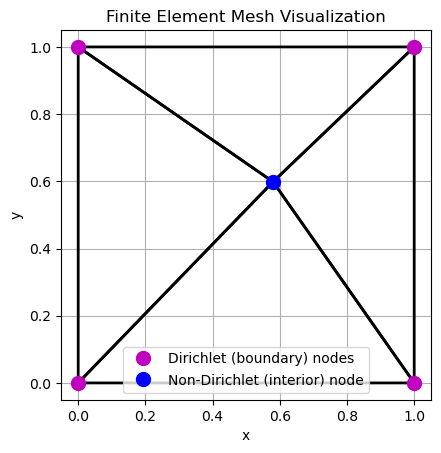

In [5]:
def visualise(nodes, elements):
    nelts, m = elements.shape   # Finds the number of elements

    # Visualizes the mesh specified by the data in nodes and elements
    plt.figure()

    for ie in range(1, nelts + 1):
        # Adjust the indexing and line plotting for accuracy
        triangle = nodes[elements[ie - 1, :], :2]  # Get coordinates of the triangle's nodes
        triangle = np.vstack([triangle, triangle[0]])  # Close the triangle
        plt.plot(triangle[:, 0], triangle[:, 1], 'k-', linewidth=2)  # Draw triangle

    # Plot the nodes on top
    # Dirichlet nodes (boundary nodes)
    ND = np.where(nodes[:, 2] == 1)[0]
    plt.plot(nodes[ND, 0], nodes[ND, 1], 'mo', markersize=10, label='Dirichlet (boundary) nodes')

    # Non-Dirichlet nodes (interior nodes)
    N0 = np.where(nodes[:, 2] == 0)[0]
    plt.plot(nodes[N0, 0], nodes[N0, 1], 'bo', markersize=10, label='Non-Dirichlet (interior) node')

    plt.gca().set_aspect('equal', adjustable='box')
    plt.title('Finite Element Mesh Visualization')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()

# Using the corrected function to visualize the mesh again
visualise(nodes, elements)

Uniformly refine the mesh as many times as specified in `nref`.

In [10]:
def refine(nodes, elements):
    nnodes, _ = nodes.shape
    nelts, _ = elements.shape

    newnodes = nodes.copy()
    newelements = np.zeros((4 * nelts, 3), dtype=int)
    inode = nnodes  # Start adding new nodes from here
    edgetable = {}

    for ie in range(nelts):  # Zero-based index for elements
        newloc = np.zeros(3, dtype=int)

        for edge in range(3):  # Zero-based index for edges
            n1 = elements[ie, edge]
            n2 = elements[ie, (edge + 1) % 3]

            # Sorted tuple for edge to ensure consistency regardless of order
            edge_key = tuple(sorted([n1, n2]))

            if edge_key not in edgetable:
                # Compute midpoint
                mid_point = (nodes[n1, :2] + nodes[n2, :2]) / 2
                is_boundary = nodes[n1, 2] and nodes[n2, 2]  # Boundary if both nodes are on boundary
                newnode = np.array([mid_point[0], mid_point[1], is_boundary])
                newnodes = np.vstack([newnodes, newnode])
                newloc[edge] = inode
                edgetable[edge_key] = inode
                inode += 1
            else:
                newloc[edge] = edgetable[edge_key]

        # Define new elements using old vertices and new midpoints
        n0, n1, n2 = elements[ie]
        m0, m1, m2 = newloc
        newelements[4 * ie] = [n0, m0, m2]
        newelements[4 * ie + 1] = [n1, m1, m0]
        newelements[4 * ie + 2] = [n2, m2, m1]
        newelements[4 * ie + 3] = [m0, m1, m2]

    return newnodes, newelements


In [11]:
def visited(edges, node1, node2):
    # Using a tuple of nodes as keys, where the tuple is always in a sorted order to handle bidirectionality
    edge_key = tuple(sorted((node1, node2)))

    # Check if the edge has already been visited by looking up the edge_key in the dictionary
    if edge_key in edges:
        return edges[edge_key]

    # Return 0 if the edge has not been visited
    return 0


In [12]:
# Uniform refinement of the mesh
nref = 1
for i in range(nref):
    nodes, elements = refine(nodes, elements)

nnodes, m = nodes.shape

Visualise the refined mesh (if not too fine).

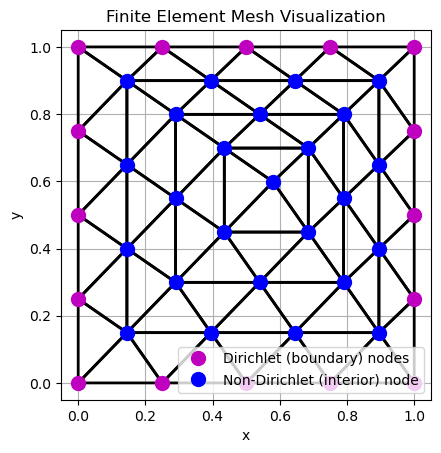

In [13]:
if nnodes < 1000:
    visualise(nodes, elements)

In [14]:
# Assuming a and b are defined somewhere earlier in your code:
a, b = 0.5798, 0.5986  # Coordinates of (a, b)

# After refining
newnodes, newelements = refine(nodes, elements)

# Find (a, b) in the new nodes list
ab_index = np.where((np.isclose(newnodes[:, 0], a, atol=1e-4) &
                     np.isclose(newnodes[:, 1], b, atol=1e-4)))[0]

if len(ab_index) == 1:
    print("The interior node (a, b) is at index", ab_index[0], "in the new nodes.")
else:
    print("Error: The interior node (a, b) was not found or duplicated in the new nodes.")


The interior node (a, b) is at index 4 in the new nodes.


In [15]:
# Confirm the coordinates of the new (a, b) node
print("Coordinates of new (a, b):", newnodes[4, :2])


Coordinates of new (a, b): [0.5798 0.5986]


Compute the element stiffness matrices.

In [16]:
def mu_area(X):
    # Takes three nodes of a triangle, listed as the rows
    # of a matrix X and finds the area of this triangle
    a = np.abs(np.linalg.det(np.column_stack((np.ones(3), X))) / 2)
    return a


In [17]:
def elt_stiffness(elements, nodes):
    nelts, m = elements.shape  # Number of elements

    elt_matrices = [None] * nelts

    for ie in range(nelts):
        elt_matrices[ie] = np.zeros((3, 3))

        # Get the coordinates of the three nodes of the element 'ie'
        # Corrected for zero-based indexing
        X = nodes[elements[ie], :2]

        # Calculate the area of the triangle
        area = mu_area(X)

        # Calculate edge vectors
        E = np.array([X[1] - X[2], X[2] - X[0], X[0] - X[1]])

        # Compute the stiffness matrix using the dot product of edge vectors
        Atau = np.zeros((3, 3))
        for i in range(3):
            for j in range(3):
                Atau[i, j] = np.dot(E[i], E[j])

        # Normalize by the factor of 4*area
        elt_matrices[ie] = Atau / (4 * area)

    return elt_matrices


In [18]:
elt_matrices = elt_stiffness(elements, nodes)

Assemble the global extended stiffness matrix.

In [19]:
from scipy.sparse import coo_matrix, csr_matrix

def global_stiffness(elt_matrices, elements, nodes):
    nelts, _ = elements.shape
    nnodes, _ = nodes.shape

    # Preparing data structures for COO format
    data = []
    row_indices = []
    col_indices = []

    # Assemble the global stiffness matrix
    for ie in range(nelts):
        iglob = elements[ie, :]  # Global indices of the current element's nodes
        for i in range(3):  # Assuming each element has 3 nodes (triangular elements)
            for j in range(3):
                data.append(elt_matrices[ie][i, j])
                row_indices.append(iglob[i])
                col_indices.append(iglob[j])

    # Create a COO matrix and convert it to CSR format
    Ahat = coo_matrix((data, (row_indices, col_indices)), shape=(nnodes, nnodes)).tocsr()

    return Ahat


In [20]:
Ahat = global_stiffness(elt_matrices, elements, nodes)

Select appropriate blocks of $\hat{A}$ to get the stiffness matrix $A$.

In [21]:
N0 = np.where(nodes[:, 2] != 1)[0]
A = Ahat[N0][:, N0]
print(A[:5, :5].todense()) 

[[4.13319848 0.         0.         0.         0.        ]
 [0.         3.75227899 0.         0.         0.        ]
 [0.         0.         4.17584224 0.         0.        ]
 [0.         0.         0.         4.51392582 0.        ]
 [0.         0.         0.         0.         4.09036257]]


Define the source term for Poisson's equation.

In [22]:
def source_term(x1, x2):
    e = np.exp(1)  # Euler's number
    return -e**x1 * ((x1 + 3) * (x2 - 1) * x2 + 2 * (x1 - 1))
f_obj = source_term

Compute the load vector.

In [23]:
def rhs(func, N0, elements, nodes):
    nelts, _ = elements.shape  # Number of elements
    nnodes, _ = nodes.shape    # Number of nodes

    fhat = np.zeros(nnodes)    # Initialize with a vector of zeros

    for ie in range(nelts):
        # Get the coordinates of the three nodes of element 'ie'
        X = nodes[elements[ie], :2]  # Zero-based indexing

        area = mu_area(X)  # Calculate the area of the element

        # Distribute the force contribution to each node
        for p in range(3):  # 3 nodes per element (assuming triangular elements)
            i = elements[ie, p]  # Zero-based node index
            fhat[i] += func(X[p, 0], X[p, 1]) * area / 3  # Function evaluated at each node

    return fhat[N0]  # Return only the non-Dirichlet part


In [24]:
f = rhs(f_obj, N0, elements, nodes)

Solve the linear system to get the FEM solution coefficients.

In [25]:
U = spsolve(A, f)

Compute the extended vector $\hat{U}$.

In [26]:
Uhat = np.zeros(nnodes)
Uhat[N0] = U

Plot the FEM solution.

Text(0.5, 0.92, 'Numerical solution')

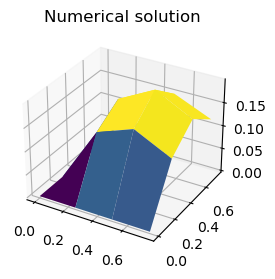

In [27]:
h_unif = 1 / (2 ** (nref + 1)) # to have a regular grid size comparable to the one used for FEM computations
XI, YI = np.meshgrid(np.arange(min(nodes[:, 0]), max(nodes[:, 0]), h_unif),
                     np.arange(min(nodes[:, 1]), max(nodes[:, 1]), h_unif))
ZI = griddata(nodes[:,:2], Uhat, (XI, YI), method='linear')

fig = plt.figure()
ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(XI, YI, ZI, cmap='viridis')
ax.set_title('Numerical solution')

In [28]:
print(U)

[0.18759102 0.15011925 0.11675108 0.09292188 0.12181002 0.06191979
 0.10757051 0.17229355 0.1750206  0.20280922 0.10280007 0.04639867
 0.15215222 0.13282809 0.0693491  0.03158634 0.07445592 0.10470882
 0.04366531 0.09850393 0.17470555 0.18017703 0.08195385 0.07755145
 0.14290146]


Evaluate the exact solution at the nodes.

In [29]:
def exact_solution(x1, x2):
    return x1 * (1 - x1) * np.exp(x1) * x2 * (1 - x2)
# Evaluate the exact solution at each node of the initial mesh
exact_at_nodes = np.array([exact_solution(node[0], node[1]) for node in nodes])

# Extract the (a, b) coordinates from the nodes array
# It is the interior node, which should be the last in our nodes list
a, b = nodes[4, :2]

# Compute the exact solution at (a, b)
exact_at_ab = exact_solution(a, b)

# Show the exact solution at nodes and at (a, b)
exact_at_nodes, exact_at_ab

(array([0.        , 0.        , 0.        , 0.        , 0.10453273,
        0.05769106, 0.04412928, 0.        , 0.05865494, 0.        ,
        0.        , 0.07668073, 0.        , 0.01823204, 0.03437519,
        0.        , 0.07988052, 0.0681031 , 0.0939172 , 0.        ,
        0.03260936, 0.01293456, 0.09007911, 0.06837516, 0.        ,
        0.03940077, 0.02077101, 0.03202204, 0.        , 0.        ,
        0.04513697, 0.02927798, 0.05553774, 0.        , 0.08938816,
        0.10590789, 0.        , 0.05520152, 0.05236586, 0.        ,
        0.09052   ]),
 0.10453272703389084)

In [30]:
a, b = nodes[4, :2]

# Print the coordinates (a, b)
print("Coordinates of (a, b):", a, b)

Coordinates of (a, b): 0.5798 0.5986


Plot the exact solution.

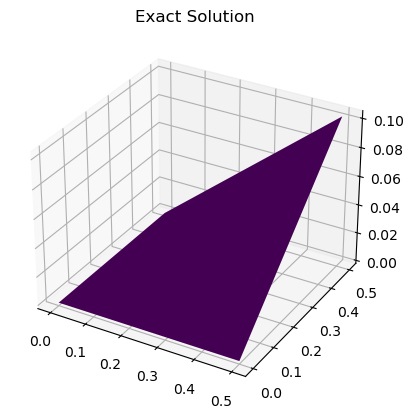

In [31]:
def source_term(x1, x2):
    e = np.exp(1)  # Euler's number
    return -e**x1 * ((x1 + 3) * (x2 - 1) * x2 + 2 * (x1 - 1))

# Define the exact solution given by the user
def exact_solution(x1, x2):
    return x1 * (1 - x1) * np.exp(x1) * x2 * (1 - x2)

# Now, let's plot the exact solution on a meshgrid to visualize it
h_unif = 1 / 2  # assuming a coarse grid for visualization
XI, YI = np.meshgrid(np.arange(0, 1, h_unif), np.arange(0, 1, h_unif))
ZI_exact = exact_solution(XI, YI)

# Plotting the exact solution
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(XI, YI, ZI_exact, cmap='viridis')
ax.set_title('Exact Solution')

plt.show()

Calculate error at nodes and plot it.

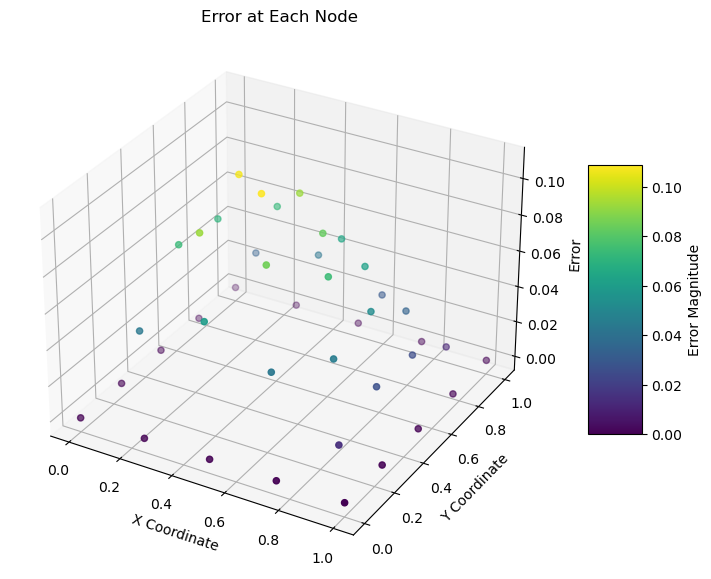

In [32]:
# Define the exact solution function
def exact_solution(x1, x2):
    return x1 * (1 - x1) * np.exp(x1) * x2 * (1 - x2)

# Calculate the exact solution at each node
exact_at_nodes = np.array([exact_solution(node[0], node[1]) for node in nodes])

# Calculate the error at each node using Uhat and exact_at_nodes
error_at_nodes = np.abs(exact_at_nodes - Uhat)

# Plot the error at each node
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Extract X, Y coordinates
X, Y = nodes[:, 0], nodes[:, 1]

# Scatter plot for errors
scatter = ax.scatter(X, Y, error_at_nodes, c=error_at_nodes, cmap='viridis', depthshade=True)

# Adding labels and title
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Error')
ax.set_title('Error at Each Node')

# Adding a color bar to interpret the error magnitudes
color_bar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=5)
color_bar.set_label('Error Magnitude')

plt.show()

Calculate the measure for the error (energy norm).

In [33]:
def energy_norm_element_wise(elt_matrices, elements, nodes, Uhat):
    energy_norm = 0
    for ie, elt in enumerate(elements):
        # Get the indices of the nodes for this element
        node_indices = elements[ie]
        # Get the values of Uhat for these nodes
        u_h_values = Uhat[node_indices]
        # Get the exact values for these nodes
        u_values = np.array([exact_solution(nodes[idx, 0], nodes[idx, 1]) for idx in node_indices])
        # Calculate the error for these nodes
        e_values = u_values - u_h_values
        # Get the area of the element
        area = mu_area(nodes[node_indices, :2])
        # Approximate the integral of the square of the gradient over the element using the stiffness matrix
        energy_norm += (e_values @ elt_matrices[ie] @ e_values) * area
    return np.sqrt(energy_norm)

# Calculate the energy norm for the error
energy_norm_error = energy_norm_element_wise(elt_matrices, elements, nodes, Uhat)
energy_norm_error

0.03395265353692902

In [34]:
# Interpolate the solution values at the specified points (a, b) and (0.92, 0.2)
uh_at_ab = griddata(nodes[:,:2], Uhat, [(a, b)], method='linear')[0]
uh_at_point = griddata(nodes[:,:2], Uhat, [(0.92, 0.2)], method='linear')[0]

# Compute the exact solution at the specified points
exact_at_ab = exact_solution(a, b)
exact_at_point = exact_solution(0.92, 0.2)

# Compute the absolute errors
error_at_ab = abs(exact_at_ab - uh_at_ab)
error_at_point = abs(exact_at_point - uh_at_point)

# Print the absolute errors
print("Absolute error at (a, b):", error_at_ab)
print("Absolute error at (0.92, 0.2):", error_at_point)


Absolute error at (a, b): 0.08305828884134374
Absolute error at (0.92, 0.2): 0.0073474565723627636


### Question 2

In [36]:
def run_simulation(num_refinements, initial_nodes,initial_elements):
    nodes, elements = np.copy(initial_nodes), np.copy(initial_elements)
    for i in range(num_refinements):
        nodes, elements = refine(nodes, elements)
    
    elt_matrices = elt_stiffness(elements, nodes)
    Ahat = global_stiffness(elt_matrices, elements, nodes)
    N0 = np.where(nodes[:, 2] != 1)[0]
    A = Ahat[N0][:, N0]
    f = rhs(exact_solution, N0, elements, nodes)
    U = spsolve(A, f)
    Uhat = np.zeros(len(nodes))
    Uhat[N0] = U
    return Uhat, nodes, elements

# Initialize the mesh
initial_nodes = np.array([[0.0, 0.0, 1],
                          [1.0, 0.0, 1],
                          [1.0, 1.0, 1],
                          [0.0, 1.0, 1],
                          [0.5798, 0.5986, 0]])  # Interior node (a, b)

initial_elements = np.array([[0, 4, 3],
                             [4, 2, 3],
                             [0, 1, 4],
                             [1, 2, 4]])

# Points to evaluate absolute error
points = [(a, b), (0.92, 0.2)]

# Number of refinements for each mesh size
num_refinements_list = [2, 3, 4, 5, 6]

# Run the simulation for each mesh size and collect the results
for num_refinements in num_refinements_list:
    Uhat, nodes, elements = run_simulation(num_refinements, initial_nodes, initial_elements)
    # Interpolate the FEM solution at the points of interest
    interpolated_values = griddata(nodes[:, :2], Uhat, points, method='linear')
    # Evaluate the exact solution at the points of interest
    exact_values = [exact_solution(*pt) for pt in points]
    # Calculate and print the absolute errors at the points (a, b) and (0.92, 0.2)
    errors = np.abs(exact_values - interpolated_values)
    print(f"Mesh refinement level {num_refinements}:")
    for pt, error in zip(points, errors):
        print(f"Absolute error at {pt}: {error:.6f}")
    print("-------------------------------------------------------")


Mesh refinement level 2:
Absolute error at (0.5798, 0.5986): 0.099386
Absolute error at (0.92, 0.2): 0.028627
-------------------------------------------------------
Mesh refinement level 3:
Absolute error at (0.5798, 0.5986): 0.099278
Absolute error at (0.92, 0.2): 0.028550
-------------------------------------------------------
Mesh refinement level 4:
Absolute error at (0.5798, 0.5986): 0.099228
Absolute error at (0.92, 0.2): 0.028547
-------------------------------------------------------
Mesh refinement level 5:
Absolute error at (0.5798, 0.5986): 0.099209
Absolute error at (0.92, 0.2): 0.028550
-------------------------------------------------------
Mesh refinement level 6:
Absolute error at (0.5798, 0.5986): 0.099203
Absolute error at (0.92, 0.2): 0.028549
-------------------------------------------------------


In [37]:
# Absolute error values for each point and each mesh refinement level
errors = {
    (0.5798, 0.5986): [0.099386, 0.099278, 0.099228, 0.099209, 0.099203],
    (0.92, 0.2): [0.028627, 0.028550, 0.028547, 0.028550, 0.028549]
}

# Mesh refinement levels
refinement_levels = [2, 3, 4, 5, 6]

# Since the mesh size h is halved with each refinement, the ratio of consecutive mesh sizes is 2
h_ratio = 2

# Calculate convergence rates for each point
convergence_rates = {}
for point, error_values in errors.items():
    rates = []
    for i in range(1, len(error_values)):
        rate = np.log(error_values[i-1] / error_values[i]) / np.log(h_ratio)
        rates.append(rate)
    convergence_rates[point] = rates

# Print convergence rates
print("Convergence rates:")
for point, rates in convergence_rates.items():
    print(f"At point {point}:")
    for i, rate in enumerate(rates, start=2):
        print(f"Refinement {i-1}-{i}: {rate:.4f}")
    print("----------------------------")


Convergence rates:
At point (0.5798, 0.5986):
Refinement 1-2: 0.0016
Refinement 2-3: 0.0007
Refinement 3-4: 0.0003
Refinement 4-5: 0.0001
----------------------------
At point (0.92, 0.2):
Refinement 1-2: 0.0039
Refinement 2-3: 0.0002
Refinement 3-4: -0.0002
Refinement 4-5: 0.0001
----------------------------


In [36]:
def convergence_rate(errors, mesh_sizes):
    rates = []
    for i in range(1, len(errors)):
        rate = np.log(errors[i] / errors[i-1]) / np.log(mesh_sizes[i] / mesh_sizes[i-1])
        rates.append(rate)
    return rates

# Convert list of points to tuple of points
points = [(0.5798, 0.5986), (0.92, 0.2)]

# List to store errors and mesh sizes
errors_at_points = {point: [] for point in points}
mesh_sizes = []

# Run the simulation for each mesh size and collect the results
for num_refinements in num_refinements_list:
    Uhat, nodes, elements = run_simulation(num_refinements, initial_nodes, initial_elements)
    interpolated_values = griddata(nodes[:, :2], Uhat, points, method='linear')
    exact_values = [exact_solution(*pt) for pt in points]
    errors = np.abs(exact_values - interpolated_values)
    
    # Store errors and mesh size
    for i, pt in enumerate(points):
        errors_at_points[pt].append(errors[i])
    mesh_sizes.append(1 / (2 ** num_refinements))  # Assuming uniform refinement

# Calculate convergence rates for each point
rates_at_points = {}
for point, errors in errors_at_points.items():
    rates_at_points[point] = convergence_rate(errors, mesh_sizes)

# Print convergence rates
print("Convergence rates:")
for point, rates in rates_at_points.items():
    print(f"At point {point}:")
    for i, rate in enumerate(rates, start=2):
        print(f"Refinement {i-1}-{i}: {rate:.4f}")
    print("----------------------------")


Convergence rates:
At point (0.5798, 0.5986):
Refinement 1-2: 0.0016
Refinement 2-3: 0.0007
Refinement 3-4: 0.0003
Refinement 4-5: 0.0001
----------------------------
At point (0.92, 0.2):
Refinement 1-2: 0.0039
Refinement 2-3: 0.0002
Refinement 3-4: -0.0002
Refinement 4-5: 0.0000
----------------------------


In [39]:
def compute_H1_error(U_ex, U, A):
    difference = U_ex - U
    error_squared = np.dot(difference, A.dot(difference))  # (U_ex - U)^T * A * (U_ex - U)
    return np.sqrt(error_squared)

def compute_exact_solution_coeffs(nodes, exact_solution):
    return np.array([exact_solution(node[0], node[1]) for node in nodes])

def run_simulation(num_refinements, initial_nodes, initial_elements, exact_solution):
    nodes, elements = np.copy(initial_nodes), np.copy(initial_elements)
    for i in range(num_refinements):
        nodes, elements = refine(nodes, elements)

    elt_matrices = elt_stiffness(elements, nodes)
    Ahat = global_stiffness(elt_matrices, elements, nodes)
    N0 = np.where(nodes[:, 2] != 1)[0]
    
    A = Ahat[N0][:, N0]
    f = rhs(exact_solution, N0, elements, nodes)
    U = spsolve(A, f)
    Uhat = np.zeros(len(nodes))
    Uhat[N0] = U
    U_ex = compute_exact_solution_coeffs(nodes[N0], exact_solution)

    
    H1_error = compute_H1_error(U_ex, U, A)
    return H1_error, Uhat, nodes, elements


# Initialize the mesh
initial_nodes = np.array([[0.0, 0.0, 1],
                          [1.0, 0.0, 1],
                          [1.0, 1.0, 1],
                          [0.0, 1.0, 1],
                          [0.5798, 0.5986, 0]])  # Interior node (a, b)

initial_elements = np.array([[0, 4, 3],
                             [4, 2, 3],
                             [0, 1, 4],
                             [1, 2, 4]])


# Run the simulation for each mesh size and collect the results
H1_errors = []
for num_refinements in [2, 3, 4, 5, 6]:
    H1_error, Uhat, nodes, elements = run_simulation(num_refinements, initial_nodes, initial_elements, exact_solution)
    H1_errors.append(H1_error)
    print(f"Mesh refinement level {num_refinements}: H1 Error = {H1_error:.6f}")

# Calculate convergence rates
convergence_rates = [log(H1_errors[i-1] / H1_errors[i]) / log(2) for i in range(1, len(H1_errors))]

# Output results with convergence rates
print("Mesh refinement level | H1 Error | Convergence Rate")
for i, error in enumerate(H1_errors, start=2):
    rate = 'N/A' if i == 2 else f"{convergence_rates[i-3]:.6f}"
    print(f"{i:20}: {error:.6f} | {rate}")


Mesh refinement level 2: H1 Error = 0.242462
Mesh refinement level 3: H1 Error = 0.248354
Mesh refinement level 4: H1 Error = 0.249846
Mesh refinement level 5: H1 Error = 0.250220
Mesh refinement level 6: H1 Error = 0.250314
Mesh refinement level | H1 Error | Convergence Rate
                   2: 0.242462 | N/A
                   3: 0.248354 | -0.034635
                   4: 0.249846 | -0.008645
                   5: 0.250220 | -0.002159
                   6: 0.250314 | -0.000540


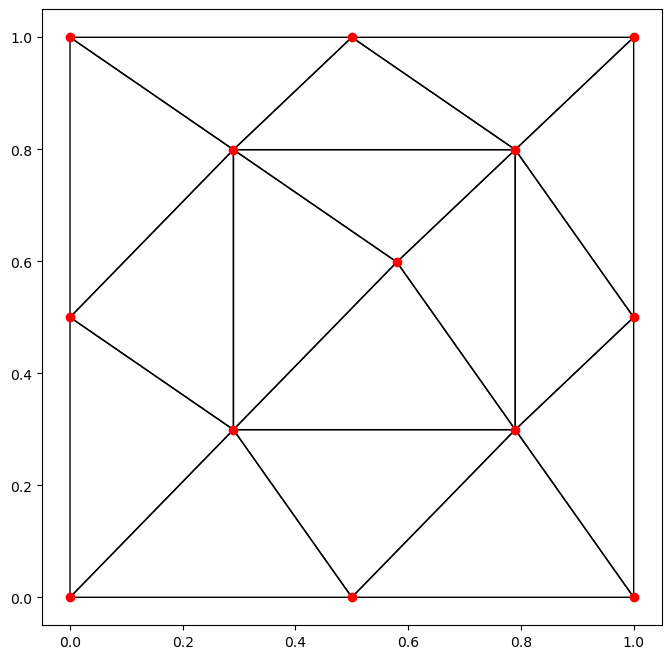

In [40]:
import matplotlib.pyplot as plt

def plot_mesh(nodes, elements):
    plt.figure(figsize=(8, 8))
    for elt in elements:
        x = nodes[elt, 0]
        y = nodes[elt, 1]
        plt.fill(x, y, edgecolor='k', fill=False)
    plt.scatter(nodes[:, 0], nodes[:, 1], color='r')  # Plot nodes
    plt.show()

# Example usage:
nodes, elements = refine(initial_nodes, initial_elements)
plot_mesh(nodes, elements)
